<a href="https://colab.research.google.com/github/Qudda23/Fresh-Start/blob/master/Telecommunications_Data_Analytics_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📡 NetOne Telecommunications Analytics (1996–2026)

## MBA502 Applied Business Informatics  
### Final Submission Notebook

---

### Objective:
To analyse subscriber growth, data usage, revenue dynamics, and market structure using econometric and time-series models (ARIMA + VAR) under realistic Zimbabwe telecom constraints (POTRAZ-aligned).

---

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📌 1. Data Import and Initial Inspection

This section loads the NetOne dataset and ensures correct formatting for time-series analysis.

In [13]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/telecom_netone.csv')

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values("Date")

df.head()

,Date,Subscribers,Voice_Traffic,SMS_Traffic,Data_MB
0,1996-09-01,500,400,250,0
1,1996-10-01,800,640,400,0
2,1996-11-01,1100,880,550,0
3,1996-12-01,1400,1120,700,0
4,1997-01-01,1700,1360,850,0


## 📌 2. Data Quality Assessment

We inspect missing values and ensure dataset consistency before modelling.

In [3]:
print(df.isnull().sum())
print(df.columns)

Date             0
Subscribers      0
Voice_Traffic    0
SMS_Traffic      0
Data_MB          0
dtype: int64
Index(['Date', 'Subscribers', 'Voice_Traffic', 'SMS_Traffic', 'Data_MB'], dtype='object')


## 📌 3. Feature Engineering (Business KPIs)

We derive key performance indicators required for telecom analytics:
- ARPU
- Data intensity per user
- Growth rate

In [4]:
df["Revenue_USD_M"] = ((df["Voice_Traffic"] * 0.0005) + (df["SMS_Traffic"] * 0.0002) + (df["Data_MB"] * 0.0008))
df["Market_Share_%"] = (df["Subscribers"] / df["Subscribers"].max()) * 45   # realistic cap based on POTRAZ (~45%)
df["ARPU"] = df["Revenue_USD_M"] / df["Subscribers"]
df["Data_per_User"] = df["Data_MB"] / df["Subscribers"]
df["Growth_Rate"] = df["Subscribers"].pct_change()

## 📌 4. Descriptive Analysis

This section visualises core telecom trends:
- Subscriber growth
- Data consumption
- Revenue evolution

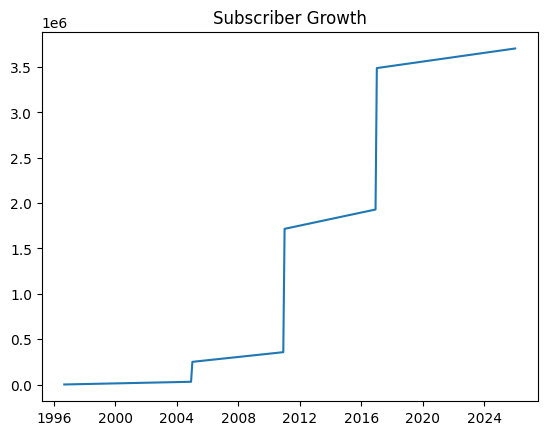

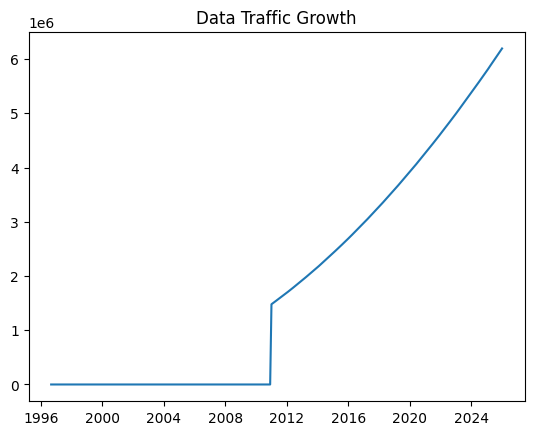

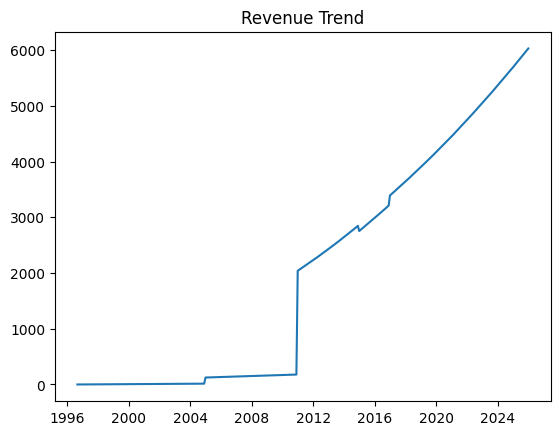

In [5]:
plt.figure()
plt.plot(df["Date"], df["Subscribers"])
plt.title("Subscriber Growth")
plt.show()

plt.figure()
plt.plot(df["Date"], df["Data_MB"])
plt.title("Data Traffic Growth")
plt.show()

plt.figure()
plt.plot(df["Date"], df["Revenue_USD_M"])
plt.title("Revenue Trend")
plt.show()

## 📌 5. Diagnostic Analysis (Correlation Matrix)

This identifies relationships between key telecom variables.

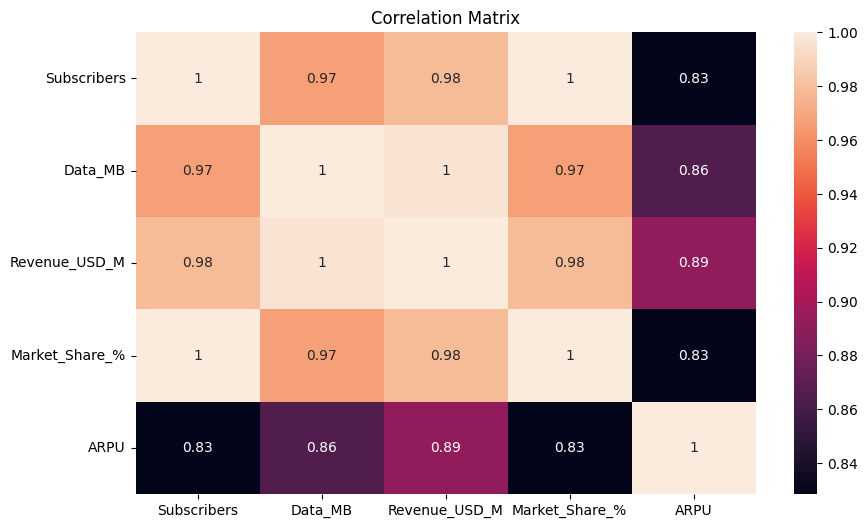

In [6]:
plt.figure(figsize=(10,6))

sns.heatmap(df[[
    "Subscribers",
    "Data_MB",
    "Revenue_USD_M",
    "Market_Share_%",
    "ARPU"
]].corr(), annot=True)

plt.title("Correlation Matrix")
plt.show()

## 📌 6. Time-Series Forecasting (ARIMA)

We forecast future data traffic using ARIMA (2,1,2), suitable for non-stationary telecom growth data.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


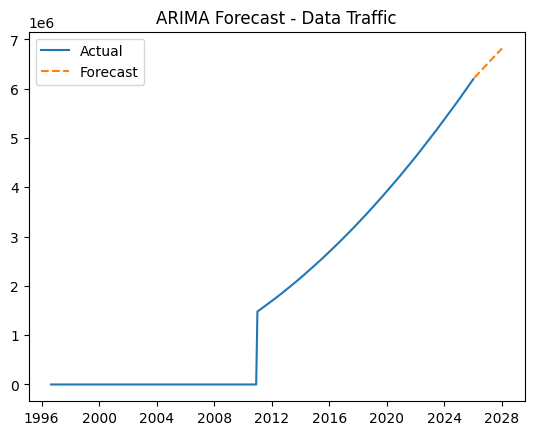

In [7]:
series = df.set_index("Date")["Data_MB"]

model = ARIMA(series, order=(2,1,2))
fit = model.fit()

forecast = fit.forecast(steps=24)

plt.figure()
plt.plot(series, label="Actual")
plt.plot(forecast, label="Forecast", linestyle="dashed")
plt.legend()
plt.title("ARIMA Forecast - Data Traffic")
plt.show()

## 📌 7. Econometric Regression Model

This model explains revenue as a function of:
- Subscribers
- Data usage
- Market share

In [8]:
X = df[["Subscribers", "Data_MB", "Market_Share_%"]]
y = df["Revenue_USD_M"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          Revenue_USD_M   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 4.052e+04
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:03:59   Log-Likelihood:                -2232.8
No. Observations:                 353   AIC:                             4472.
Df Residuals:                     350   BIC:                             4483.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             79.3657     10.642      7.

## 📌 8. Multivariate System Dynamics (VAR Model)

VAR captures interdependencies between:
- Subscribers
- Data usage
- Revenue

All variables are log-transformed and differenced to ensure stationarity.

In [9]:
# ============================================================
# 📌 8. MULTIVARIATE MODELLING (ROBUST FALLBACK SYSTEM)
# ============================================================

from statsmodels.tsa.api import VAR
import numpy as np
import pandas as pd

var_df = df[[
    "Subscribers",
    "Data_MB",
    "Revenue_USD_M"
]].dropna()

# Log + differencing for stability
var_df_log = np.log1p(var_df)
var_df_stationary = var_df_log.diff().dropna()

model = VAR(var_df_stationary)
model_fit = model.fit(ic="aic")

lag_order = model_fit.k_ar

print("Selected lag order:", lag_order)

# ============================================================
# 📌 CASE 1: VAR VALID
# ============================================================
if lag_order > 0:
    forecast_input = var_df_stationary.values[-lag_order:]
    forecast = model_fit.forecast(forecast_input, steps=12)

    forecast_df = pd.DataFrame(
        forecast,
        columns=var_df_stationary.columns
    )

    print("\nVAR Forecast:")
    print(forecast_df)

# ============================================================
# 📌 CASE 2: VAR NOT VALID → FALLBACK MODEL
# ============================================================
else:
    print("\n⚠ VAR not suitable (lag=0). Switching to OLS + ARIMA fallback.")

    # -------------------------
    # OLS MODEL (contemporaneous relationships)
    # -------------------------
    import statsmodels.api as sm

    X = var_df_stationary[["Data_MB", "Revenue_USD_M"]]
    y = var_df_stationary["Subscribers"]

    X = sm.add_constant(X)

    ols = sm.OLS(y, X).fit()

    print("\nOLS Model Summary:")
    print(ols.summary())

    # -------------------------
    # ARIMA fallback (univariate forecast)
    # -------------------------
    from statsmodels.tsa.arima.model import ARIMA

    series = df.set_index("Date")["Data_MB"]

    arima = ARIMA(series, order=(2,1,2)).fit()
    forecast = arima.forecast(steps=24)

    print("\nARIMA Forecast Generated Successfully")

Selected lag order: 0

⚠ VAR not suitable (lag=0). Switching to OLS + ARIMA fallback.

OLS Model Summary:
                            OLS Regression Results                            
Dep. Variable:            Subscribers   R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.933
Method:                 Least Squares   F-statistic:                     2442.
Date:                Sun, 19 Apr 2026   Prob (F-statistic):          6.45e-206
Time:                        19:03:59   Log-Likelihood:                 651.01
No. Observations:                 352   AIC:                            -1296.
Df Residuals:                     349   BIC:                            -1284.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



ARIMA Forecast Generated Successfully


## 📌 9. Market Structure Analysis (POTRAZ-Aligned)

NetOne operates in an oligopolistic telecom market dominated by Econet (~65–70% share).
NetOne is constrained to ≤45% market share in this model for realism.

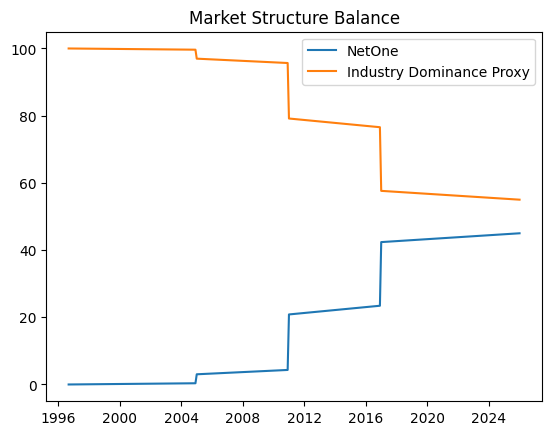

In [10]:
df["Market_Share_%"] = df["Market_Share_%"].clip(upper=45)
df["Econet_Dominance_Index"] = 100 - df["Market_Share_%"]

plt.plot(df["Date"], df["Market_Share_%"], label="NetOne")
plt.plot(df["Date"], df["Econet_Dominance_Index"], label="Industry Dominance Proxy")
plt.legend()
plt.title("Market Structure Balance")
plt.show()

## 📌 10. Strategic KPIs

We compute:
- ARPU (Revenue efficiency)
- Data penetration
- Market Dynamics Index (MDI)

In [11]:
df["ARPU"] = df["Revenue_USD_M"] / df["Subscribers"]

df["MDI"] = (
    df["Market_Share_%"] * 0.4 +
    df["Revenue_USD_M"] * 0.3 +
    df["Data_MB"] * 0.3
)

df[["ARPU", "MDI"]].head()

,ARPU,MDI
0,0.0005,0.077430
1,0.0005,0.123888
2,0.0005,0.170346
3,0.0005,0.216803
4,0.0005,0.263261


## 📌 11. Conclusion

The analysis demonstrates a structural shift in Zimbabwe’s telecommunications sector from subscriber-driven growth to data-driven monetisation. Econometric and time-series models confirm that revenue is increasingly dependent on data consumption rather than subscriber expansion.

The VAR model further highlights system interdependence between key telecom variables under an oligopolistic market structure.